In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import string
import hashlib
import json
import os
import warnings

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [55]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [56]:
CSV_PATH = "ai-medical-chatbot.csv"
df_raw = pd.read_csv(CSV_PATH, encoding='latin1', on_bad_lines='skip')
print(f"Shape      : {df_raw.shape}")
print(f"Columns    : {list(df_raw.columns)}")
print(f"Memory     : {df_raw.memory_usage(deep=True).sum()/1e6:.1f} MB")
df_raw.head()

Shape      : (513832, 3)
Columns    : ['Description', 'Patient', 'Doctor']
Memory     : 543.8 MB


,Description,Patient,Doctor
0,Q. What does abutment of the nerve root mean?,"Hi doctor,I am just wondering what is abutting...",Hi. I have gone through your query with dilige...
1,Q. What should I do to reduce my weight gained...,"Hi doctor, I am a 22-year-old female who was d...",Hi. You have really done well with the hypothy...
2,Q. I have started to get lots of acne on my fa...,Hi doctor! I used to have clear skin but since...,Hi there Acne has multifactorial etiology. Onl...
3,Q. Why do I have uncomfortable feeling between...,"Hello doctor,I am having an uncomfortable feel...",Hello. The popping and discomfort what you fel...
4,Q. My symptoms after intercourse threatns me e...,"Hello doctor,Before two years had sex with a c...",Hello. The HIV test uses a finger prick blood ...


In [57]:
print("Data Types")
print(df_raw.dtypes)
print("\nMissing Values")
print(df_raw.isnull().sum())
print("\nSample Rows")
display(df_raw.sample(3, random_state=42))

Data Types
Description    str
Patient        str
Doctor         str
dtype: object

Missing Values
Description    0
Patient        0
Doctor         0
dtype: int64

Sample Rows


,Description,Patient,Doctor
172804,What is the remedy for gas and indigestion aft...,My husband was released from hospital at 5:00 ...,"Hi,Thank you for your query. I can understand ..."
370576,Why are my lower leg muscles cramping?,On Monday evening I strained my calf muscle in...,"hi,thank you for providing the brief history o..."
64363,Suggest treatment for premature ejaculation,My left side of my penis has become more sensi...,Hellotake these medicinesâ TABLET CONFIDO 2 ...


In [59]:
df = df_raw[['Description', 'Patient', 'Doctor']].copy()

# Fill missing values
df['Description'] = df['Description'].fillna('').astype(str)
df['Patient'] = df['Patient'].fillna('').astype(str)
df['Doctor'] = df['Doctor'].fillna('').astype(str)

# Regex cleaning
JUNK_RE = re.compile(r'Â|â€™|â€œ|â€\\x9d|â€\"|\\u00e2|\\u0080|\\u0099|\\xa0')
WHITESPACE_RE = re.compile(r'\s{2,}')

def clean_text(text):
    text = JUNK_RE.sub(' ', text)
    text = WHITESPACE_RE.sub(' ', text)

    return text.strip()

df['Description'] = df['Description'].apply(clean_text)
df['Patient'] = df['Patient'].apply(clean_text)
df['Doctor'] = df['Doctor'].apply(clean_text)

# Remove short rows
df = df[(df['Patient'].str.len() > 5) & (df['Doctor'].str.len() > 5)]
df.reset_index(drop=True, inplace=True)

print(f"Rows after cleaning: {len(df):,}")
df.head()

Rows after cleaning: 513,758


,Description,Patient,Doctor
0,Q. What does abutment of the nerve root mean?,"Hi doctor,I am just wondering what is abutting...",Hi. I have gone through your query with dilige...
1,Q. What should I do to reduce my weight gained...,"Hi doctor, I am a 22-year-old female who was d...",Hi. You have really done well with the hypothy...
2,Q. I have started to get lots of acne on my fa...,Hi doctor! I used to have clear skin but since...,Hi there Acne has multifactorial etiology. Onl...
3,Q. Why do I have uncomfortable feeling between...,"Hello doctor,I am having an uncomfortable feel...",Hello. The popping and discomfort what you fel...
4,Q. My symptoms after intercourse threatns me e...,"Hello doctor,Before two years had sex with a c...",Hello. The HIV test uses a finger prick blood ...


In [60]:
before = len(df)

df['_hash'] = df.apply(lambda r: hashlib.md5(f"{r['Patient'][:200]}{r['Doctor'][:200]}".encode()).hexdigest(),axis=1)

df.drop_duplicates(subset='_hash', inplace=True)
df.drop(columns='_hash', inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f"Before dedup : {before:,}")
print(f"After dedup  : {after:,}")
print(f"Removed      : {before-after:,}")

Before dedup : 513,758
After dedup  : 443,610
Removed      : 70,148


In [61]:
def preprocess(text,remove_stops=True,lemmatize=True):
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Keep only letters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()

    if remove_stops:
        tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    if lemmatize:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['patient_clean'] = df['Patient'].apply(preprocess)
df['doctor_clean'] = df['Doctor'].apply(preprocess)

print("Original:")
print(df['Patient'].iloc[0])
print("\nProcessed:")
print(df['patient_clean'].iloc[0])

Original:
Hi doctor,I am just wondering what is abutting and abutment of the nerve root means in a back issue. Please explain. What treatment is required for annular bulging and tear?

Processed:
hi doctor wondering abutting abutment nerve root mean back issue please explain treatment required annular bulging tear


In [62]:
df['patient_tokens'] = df['patient_clean'].apply(word_tokenize)
df['doctor_tokens'] = df['doctor_clean'].apply(word_tokenize)
df['patient_token_count'] = df['patient_tokens'].apply(len)
df['doctor_token_count'] = df['doctor_tokens'].apply(len)
print(df[['patient_token_count', 'doctor_token_count']])
df.describe()

        patient_token_count  doctor_token_count
0                        17                  12
1                        49                 153
2                        63                  48
3                        70                  59
4                       111                  72
...                     ...                 ...
443605                   28                  68
443606                   41                  49
443607                   26                  19
443608                   40                  34
443609                   37                  45

[443610 rows x 2 columns]


,patient_token_count,doctor_token_count
count,443610.000000,443610.000000
mean,40.726708,50.293943
std,27.597304,29.618002
min,0.000000,0.000000
25%,27.000000,31.000000
50%,33.000000,45.000000
75%,46.000000,63.000000
max,1481.000000,1096.000000


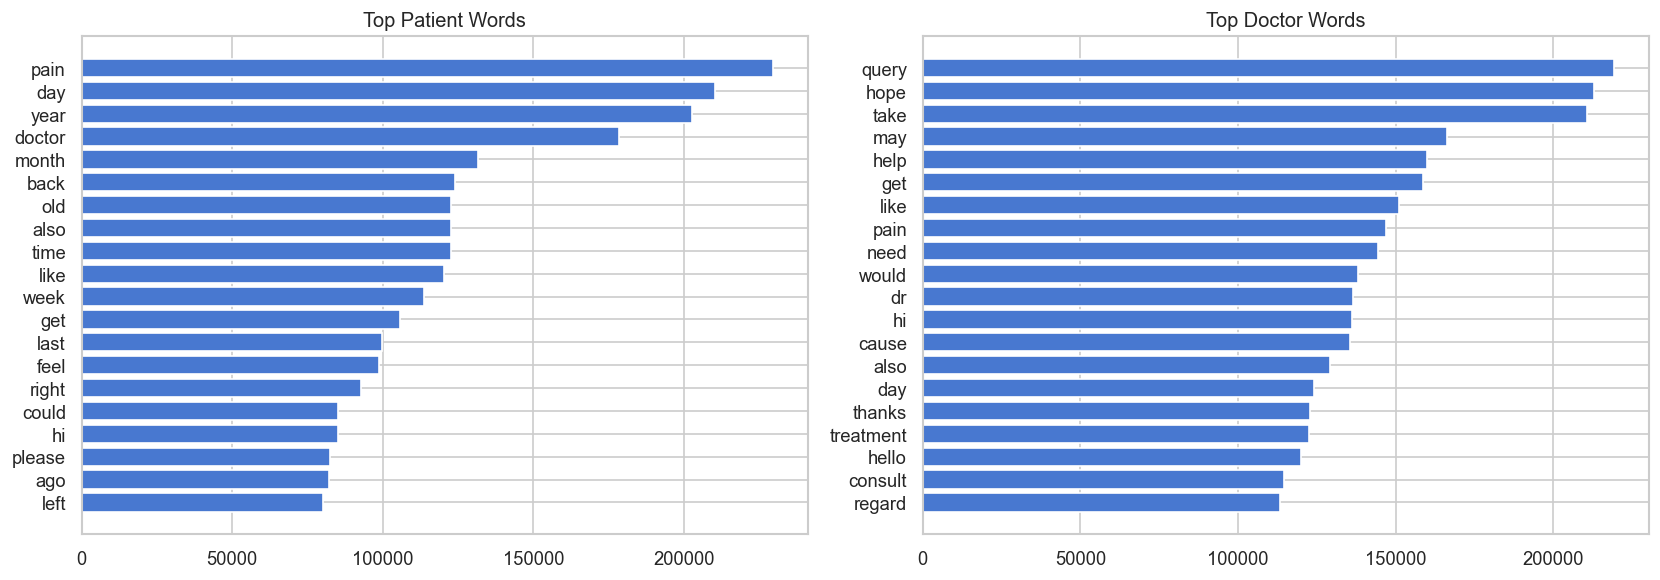

In [63]:
all_patient_tokens = [t for tokens in df['patient_tokens'] for t in tokens]
all_doctor_tokens = [t for tokens in df['doctor_tokens'] for t in tokens]

patient_freq = Counter(all_patient_tokens).most_common(20)
doctor_freq = Counter(all_doctor_tokens).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, freq, title in zip(axes, [patient_freq, doctor_freq], ['Top Patient Words', 'Top Doctor Words']):
    words, counts = zip(*freq)
    ax.barh(list(words)[::-1], list(counts)[::-1])
    ax.set_title(title)
plt.tight_layout()
plt.show()

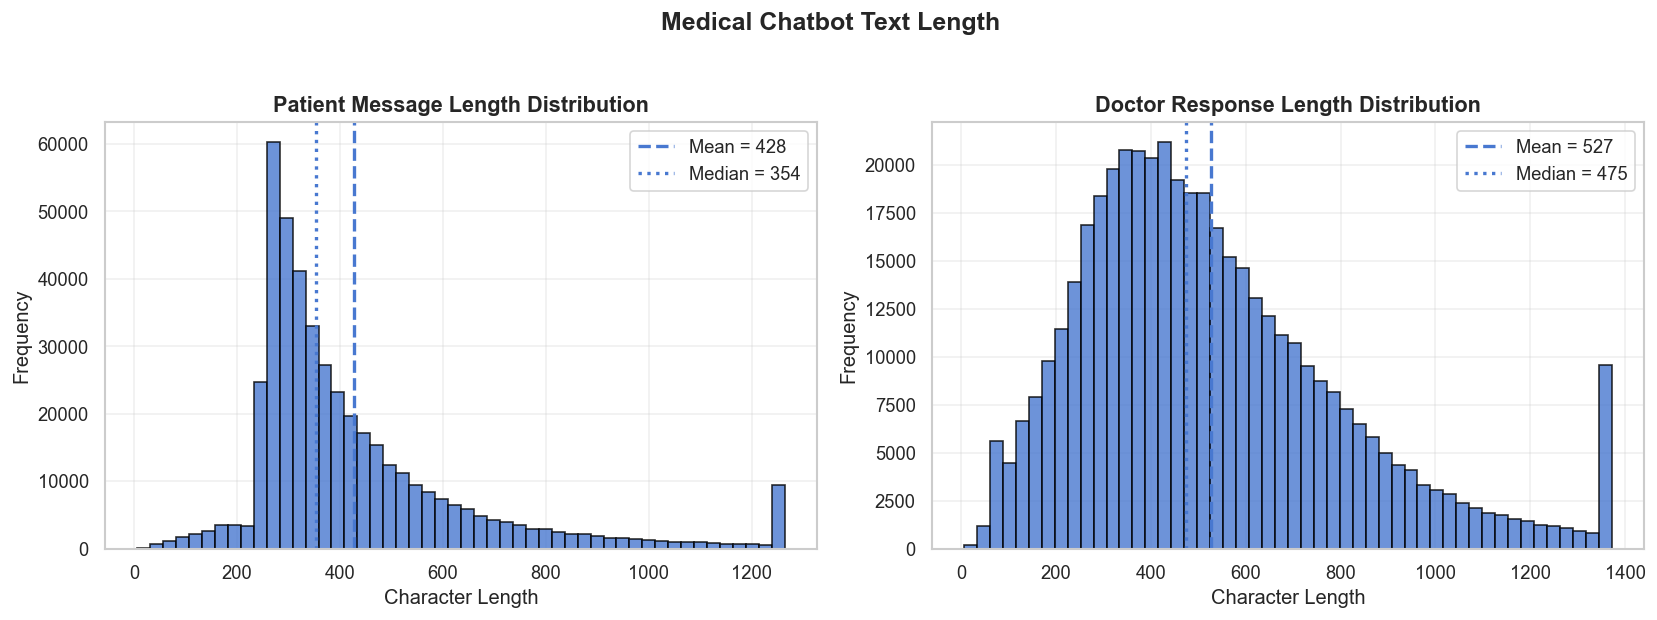

,patient_char_len,doctor_char_len
count,443610.0,443610.0
mean,440.2,534.6
std,302.6,316.1
min,6.0,6.0
25%,286.0,326.0
50%,354.0,475.0
75%,491.0,675.0
max,17763.0,11388.0


In [64]:
df['patient_char_len'] = df['Patient'].str.len()
df['doctor_char_len'] = df['Doctor'].str.len()

patient_clip = df['patient_char_len'].clip(upper=df['patient_char_len'].quantile(0.98))
doctor_clip = df['doctor_char_len'].clip(upper=df['doctor_char_len'].quantile(0.98))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(patient_clip, bins=50, edgecolor='black', alpha=0.8)
axes[0].axvline(patient_clip.mean(), linestyle='--', linewidth=2, label=f"Mean = {patient_clip.mean():.0f}")
axes[0].axvline(patient_clip.median(), linestyle=':', linewidth=2, label=f"Median = {patient_clip.median():.0f}")
axes[0].set_title('Patient Message Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Doctor Length Histogram
axes[1].hist(doctor_clip, bins=50, edgecolor='black', alpha=0.8)
axes[1].axvline(doctor_clip.mean(), linestyle='--', linewidth=2, label=f"Mean = {doctor_clip.mean():.0f}")
axes[1].axvline(doctor_clip.median(), linestyle=':', linewidth=2, label=f"Median = {doctor_clip.median():.0f}")
axes[1].set_title('Doctor Response Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Medical Chatbot Text Length',fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

summary = df[['patient_char_len', 'doctor_char_len']].describe().round(1)
display(summary)

In [65]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42
)

train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print(f"Total : {len(df):,}")
print(f"Train : {len(train_df):,}")
print(f"Test  : {len(test_df):,}")

Total : 443,610
Train : 377,068
Test  : 66,542


In [66]:
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(train_df['patient_clean'])
X_test_tfidf = tfidf.transform(test_df['patient_clean'])

print("TF-IDF Shapes")
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

TF-IDF Shapes
(377068, 8000)
(66542, 8000)


In [67]:
TOP_N = 20
top_topics = (df['Description'].value_counts().head(TOP_N).index.tolist())
df_ml = df[df['Description'].isin(top_topics)].copy()
le = LabelEncoder()
df_ml['label'] = le.fit_transform(df_ml['Description'])

X_ml_train, X_ml_test, y_ml_train, y_ml_test = train_test_split(
    df_ml['patient_clean'],
    df_ml['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_ml['label'])

tfidf_ml = TfidfVectorizer(max_features=6000, ngram_range=(1, 2))

X_tr = tfidf_ml.fit_transform(X_ml_train)
X_te = tfidf_ml.transform(X_ml_test)

print(f"ML Dataset Rows: {len(df_ml):,}")

ML Dataset Rows: 3,600


In [68]:
models = {
    'Logistic Regression':
        LogisticRegression(max_iter=500),

    'Naive Bayes':
        MultinomialNB(alpha=0.1),

    'Linear SVM':
        LinearSVC()
}

results = {}

for name, model in models.items():

    model.fit(X_tr, y_ml_train)
    preds = model.predict(X_te)
    report = classification_report(
        y_ml_test,
        preds,
        output_dict=True,
        zero_division=0
    )
    results[name] = {
        'accuracy':
            report['accuracy'],
        'macro_f1':
            report['macro avg']['f1-score']
    }
    
results_df = pd.DataFrame(results).T.round(4)
print(results_df)

                     accuracy  macro_f1
Logistic Regression    0.7903    0.7664
Naive Bayes            0.8278    0.8203
Linear SVM             0.9000    0.8979


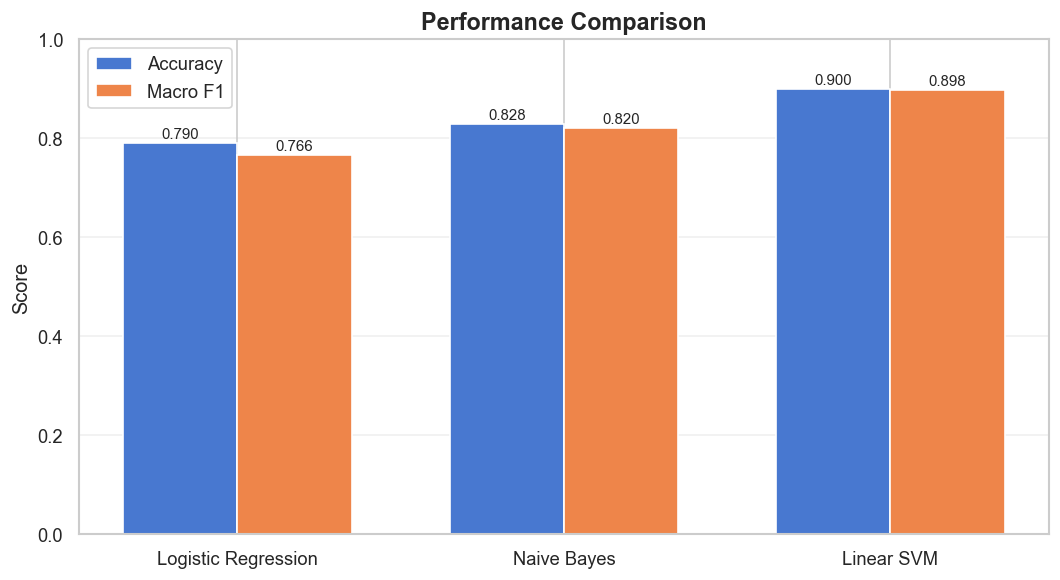

In [69]:
x = np.arange(len(results_df.index))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, results_df['accuracy'], width, label='Accuracy')
bars2 = ax.bar(x + width/2, results_df['macro_f1'], width, label='Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index)
ax.set_ylim(0, 1)
ax.set_title('Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()

# Add labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01, f'{height:.3f}',
            ha='center', fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

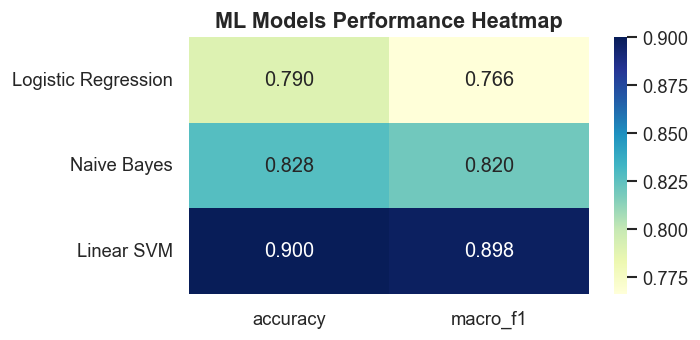

In [70]:
plt.figure(figsize=(6, 3))
sns.heatmap(results_df, annot=True, cmap='YlGnBu', fmt='.3f')

plt.title('ML Models Performance Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

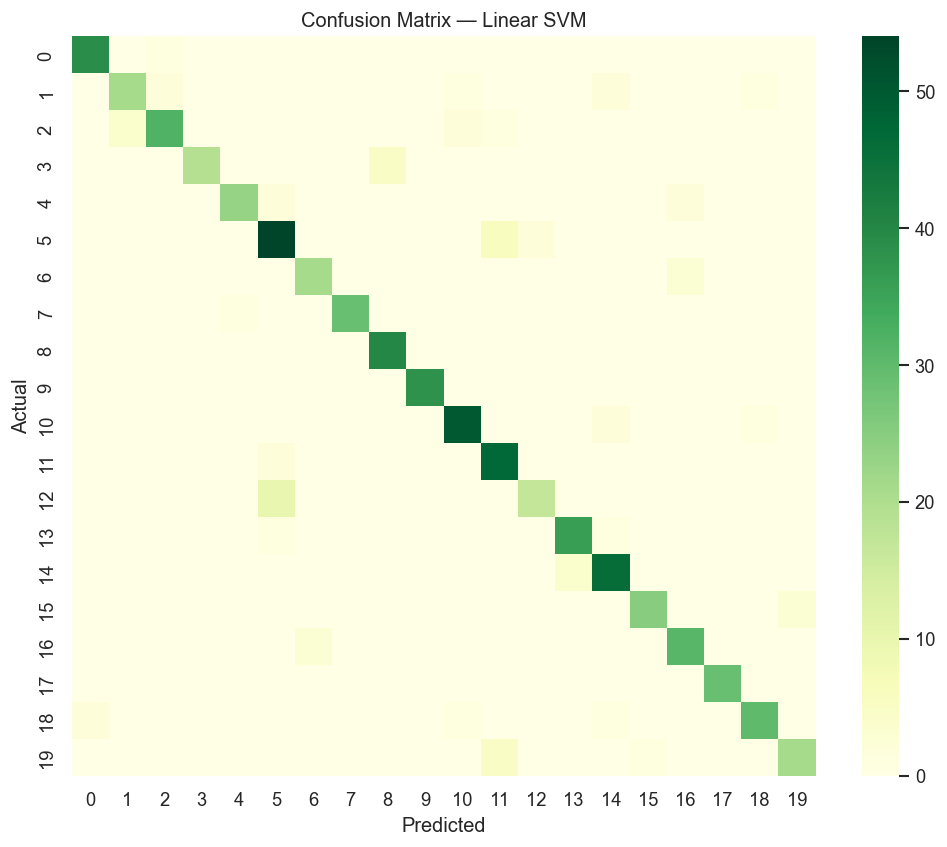

In [71]:
best_name = max(results, key=lambda k: results[k]['macro_f1'])
best_model = models[best_name]
best_preds = best_model.predict(X_te)

cm = confusion_matrix(y_ml_test, best_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='YlGn')
plt.title(f'Confusion Matrix — {best_name}')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()